In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Data/Processed/cleaned_data.csv")

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Sales        779425 non-null  float64       
 9   Month        779425 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 98.2 MB


In [7]:
df.shape

(779425, 10)

In [8]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

In [9]:
# Create daily sales dataset 
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Sales"].sum().reset_index()
)

daily_sales.columns = [
    "Date",
    "Sales"
]

daily_sales.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [10]:
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    604 non-null    object 
 1   Sales   604 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.6+ KB


In [11]:
Q1 = daily_sales["Sales"].quantile(0.25)

Q3 = daily_sales["Sales"].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outliers = daily_sales[
    daily_sales["Sales"] > upper
]

print(outliers)

           Date      Sales
2    2009-12-03   67413.62
24   2010-01-07   72989.38
243  2010-09-27  115172.24
258  2010-10-14   86945.13
276  2010-11-04   83876.12
281  2010-11-10   73575.93
282  2010-11-11   59712.61
286  2010-11-16   63788.84
294  2010-11-25   67870.96
297  2010-11-29   63245.18
325  2011-01-11   60243.73
331  2011-01-18   87559.21
424  2011-05-12   59827.74
495  2011-08-04   62074.19
530  2011-09-15   71926.69
534  2011-09-20  103377.68
545  2011-10-03   62143.07
547  2011-10-05   73975.57
548  2011-10-06   60258.53
560  2011-10-20   60910.30
561  2011-10-21   60364.01
572  2011-11-03   60536.09
577  2011-11-09   61241.58
578  2011-11-10   70373.03
589  2011-11-23   71722.75
601  2011-12-07   69230.60
603  2011-12-09  184347.66


In [12]:
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    604 non-null    datetime64[s]
 1   Sales   604 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 9.6 KB


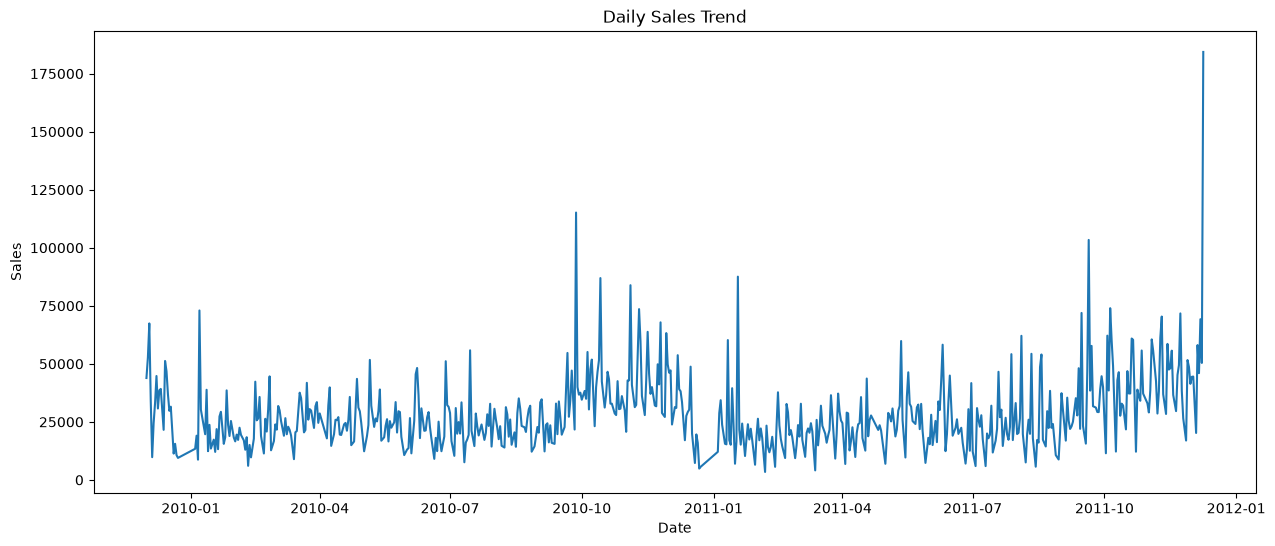

In [13]:
#plot daliy sales trend 
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title(
    "Daily Sales Trend"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [14]:
daily_sales.shape

(604, 2)

In [15]:
#create rolling averages
#7-days moving average 
#30-days moving average 
daily_sales["7_Day_MA"] = (
    daily_sales["Sales"]
    .rolling(7)
    .mean()
)

daily_sales["30_Day_MA"] = (
    daily_sales["Sales"]
    .rolling(30)
    .mean()
)

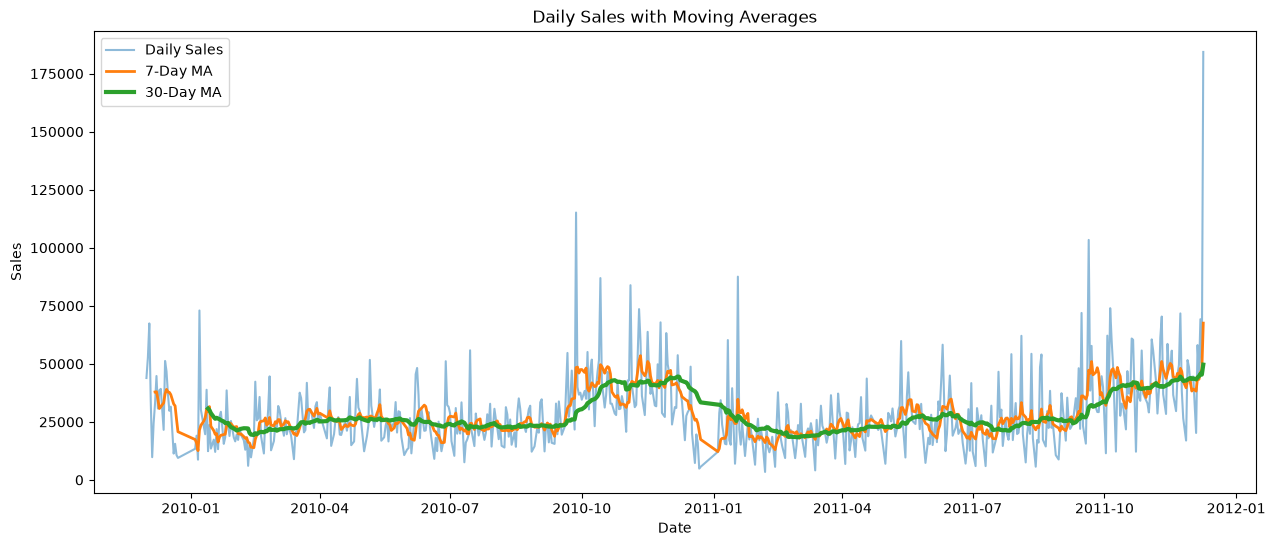

In [16]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    label="Daily Sales",
    alpha=0.5
)

plt.plot(
    daily_sales["Date"],
    daily_sales["7_Day_MA"],
    label="7-Day MA",
    linewidth=2
)

plt.plot(
    daily_sales["Date"],
    daily_sales["30_Day_MA"],
    label="30-Day MA",
    linewidth=3
)

plt.title("Daily Sales with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [17]:
# ADF Stationary test
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    daily_sales["Sales"]
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -1.6512185752853836
p-value: 0.4564049792435114
1% -3.441444394224128
5% -2.8664345376276454
10% -2.569376663737217


In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose


daily_sales_ts = daily_sales.copy()

daily_sales_ts.set_index(
    "Date",
    inplace=True
)


decomposition = seasonal_decompose(
    daily_sales_ts["Sales"],
    model="additive",
    period=30
)

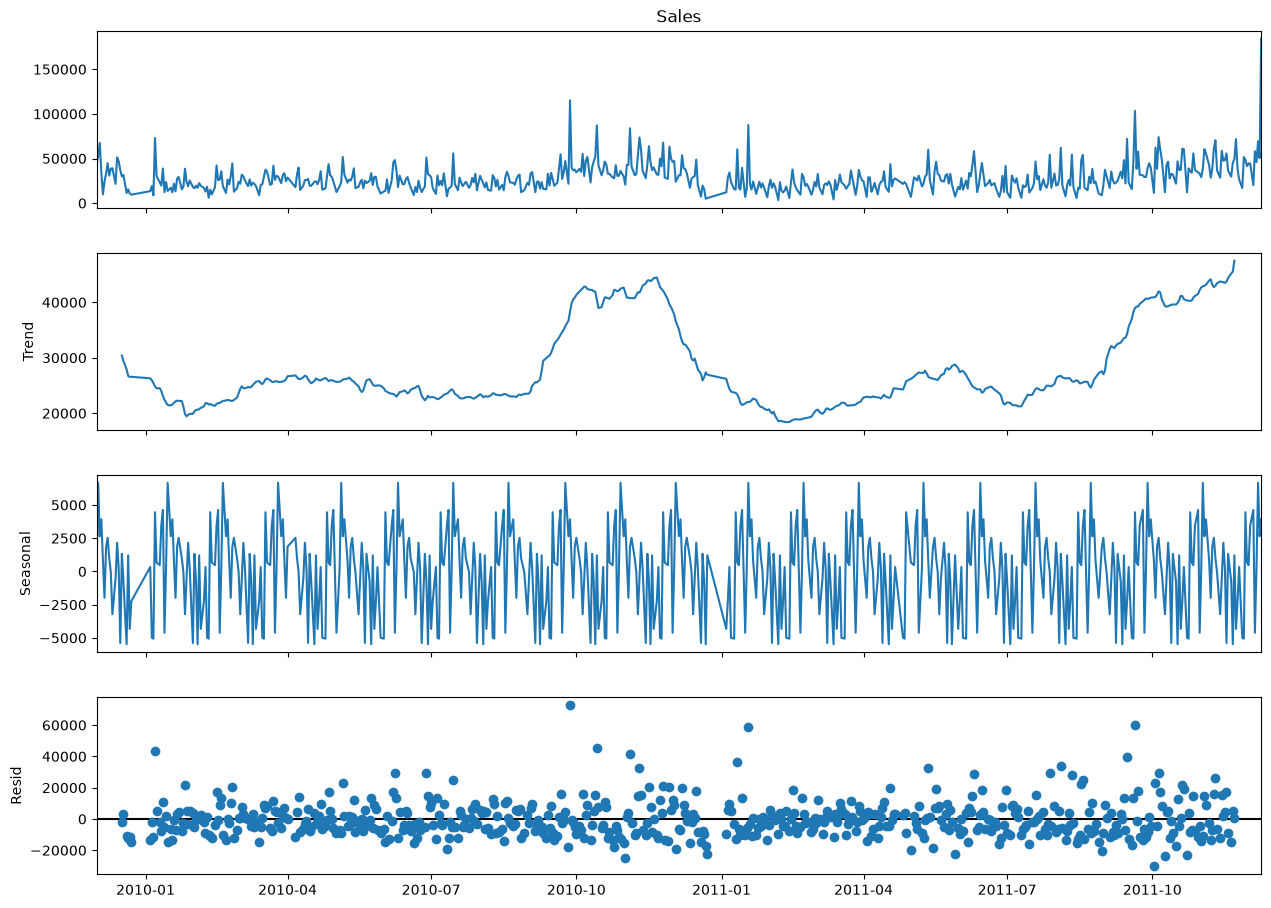

In [19]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

In [20]:
daily_sales.head(5)

,Date,Sales,7_Day_MA,30_Day_MA
0,2009-12-01,43894.87,NaN,NaN
1,2009-12-02,52762.06,NaN,NaN
2,2009-12-03,67413.62,NaN,NaN
3,2009-12-04,33913.81,NaN,NaN
4,2009-12-05,9803.05,NaN,NaN


In [21]:
#for prophet model we need only date and sales columns

prophet_df = daily_sales[
    ['Date', 'Sales']
].copy()

prophet_df.rename(
    columns={
    'Date' : 'ds',
    'Sales': 'y'
    }, inplace = True
)

prophet_df.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [22]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   ds      604 non-null    datetime64[s]
 1   y       604 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 9.6 KB


In [23]:
prophet_df.shape

(604, 2)

In [24]:
prophet_df.to_csv("Data/Processed/prophet_data.csv", index = False)